# Stage 3 – Data Understanding and Exploratory Data Analysis (EDA) Plan

**Project:** Machine Learning-Based U.S. Residential Rental Price Estimation System
**Dataset:** USA Housing Listings (Kaggle, Austin Reese) – Craigslist rental listings
**Target:** `price` – advertised monthly rent in USD (supervised regression)

---

## Purpose of this document

This document explains **what** we will do in the EDA stage, **why** each step matters, and **how** each step feeds into later preprocessing and modelling decisions. Read it before opening the notebook so the code makes sense.

The EDA covers every aspect required by the assignment brief, and goes beyond it:

| Assignment requirement | Covered in |
|---|---|
| Structure, meaning and distribution of the data | Steps 1, 2, 8 |
| Variable types and relevant relationships | Steps 1, 9, 10 |
| Missing values and duplicated records | Steps 3, 4 |
| Outliers and unusual observations | Steps 5, 6 |
| Class imbalance (where applicable) | Step 11 |
| Visualising distributions and relationships | Steps 8, 9, 10 |
| Data leakage and how it will be prevented | Steps 4, 7, 12 |
| Observations influencing preprocessing and modelling | Step 13 (built throughout) |
| **Additional (beyond brief)** | Validity checks (Step 5), geographic analysis (Step 9), leakage evidence from text (Step 12) |

---

## Key principle: avoid "data snooping"

We work in two phases:

1. **Data-quality checks on the full dataset** (Steps 1–6). Counting missing values, duplicates and invalid values is descriptive, so using all rows is fine.
2. **Relationship analysis on the training set only** (Steps 8–12). Before we study how features relate to price, we lock away a test set (Step 7).

**Why:** if we study feature–price relationships using test rows and then design features based on what we saw, information from the test set leaks into the model design. The final test score would then be over-optimistic. Keeping the test set untouched means it remains a fair, unseen evaluation.

---

## Project folder structure

```
fdm-rental-price/
├── data/
│   ├── raw/          ← original housing.csv (never edited)
│   ├── interim/      ← parquet copies, cleaned intermediate files
│   └── processed/    ← final train/test sets
├── notebooks/
│   ├── 01_eda.ipynb             ← Steps 0–1
│   └── 02_eda_target.ipynb      ← Step 2 onwards
├── src/
│   ├── __init__.py
│   └── utils.py                 ← shared paths, settings and helpers
├── reports/
│   ├── figures/                 ← all saved EDA plots
│   ├── data_dictionary.csv
│   └── observations_log.csv     ← Observation → Decision table
├── requirements.txt
└── .gitignore
```

---

## Step 0 – Setup

**Goal:** a reproducible working environment.

**What we do**
- Create a virtual environment and install: pandas, numpy, matplotlib, seaborn, scipy, statsmodels, scikit-learn, missingno (optional), pyarrow, jupyter.
- Fix one random seed (`RANDOM_STATE = 42`) used for all sampling, splitting and models.
- Load `housing.csv` once and save a parquet copy for quick reloading in later notebooks.
- Keep `df_raw` untouched; do all work on a copy `df`.
- Keep shared helpers in `src/utils.py` so every notebook uses the same ones:
  - `log_obs(step, observation, evidence, decision)` – records every finding and the decision it drives.
  - `save_fig(name)` – saves every plot into `reports/figures/` for the report.
- Use a fixed 50,000-row random sample for plots only (385k points are unreadable); all statistics use the full data.

**Output:** working notebook, parquet copy, empty observations log.

---

## Step 1 – Structure and meaning of the data

**Goal:** understand exactly what each column is before analysing anything.

**What we do**
- Check shape; view head, tail and a random sample.
- Inspect storage data types (`df.info()`) and non-null counts.
- Count unique values per column (cardinality) to classify variables.
- Inspect categorical values: `type`, `laundry_options`, `parking_options`, `state`, `region`.
- Validate that the six binary flags contain only 0 and 1.
- First-glance numeric summary (`describe()`) to spot impossible values.
- Check whether `id` / `url` are unique and whether `region_url` maps one-to-one to `region`.
- Build a **data dictionary**: column, meaning, storage type, true variable type, unique count, missing %, planned role.

**Why:** storage type ≠ variable type. Binary flags are stored as integers but are categories; `beds`/`baths` are discrete; `region` has hundreds of categories of inconsistent geographic size. These facts decide encoding and cleaning later.

**Expected findings to confirm:** identifiers (`id`, `url`, `region_url`, `image_url`) have no predictive value; `region` is high-cardinality with mixed granularity; impossible extremes exist in price and size.

**Output:** `data_dictionary.csv`, structural observations logged.

---

## Step 2 – Analyse the target variable (`price`)

**Goal:** understand the distribution of what we are predicting.

**What we do**
- Summary statistics plus extreme quantiles (0.1%, 1%, 99%, 99.9%).
- Count suspicious rents: exactly 0, below $100, above $10,000.
- Histogram of raw price and of `log1p(price)`; report skewness.

**Why:** the target distribution drives several major decisions: whether to log-transform the target, which rows are invalid, and which evaluation metrics are meaningful. Scraped rental data usually has a long right tail and some absurd values.

**Decisions this informs:** target transformation (log), plausibility filter on price, stratified splitting.

---

## Step 3 – Missing values

**Goal:** measure and understand missingness.

**What we do**
- Count and percentage of missing values per column; bar chart (and missingno matrix if available).
- Test whether missingness is informative: compare median price for rows where `laundry_options` / `parking_options` are missing versus present.
- Check missing `lat` / `long` and `description`.

**Why:** if missing rows have a different price level, the data is **not missing at random**. Imputing the most frequent value would then hide a real signal; treating "missing" as its own category preserves it.

**Decisions this informs:** imputation strategy per column ("missing" category, median imputation, or row removal), always fitted on training data only.

---

## Step 4 – Duplicate records

**Goal:** find repeated listings before splitting the data.

**What we do** – check three levels and report each count:
1. **Exact duplicates** – every column identical.
2. **Content duplicates** – identical after ignoring `id` and `url` (the same listing reposted with a new ID).
3. **Near-duplicates** – same `image_url` or `description` with same location and price.

**Why:** Craigslist listings are frequently reposted. If copies of one listing fall into both training and test sets, the model is effectively tested on data it has already seen, which inflates scores. This is a form of **data leakage**.

**Decisions this informs:** remove duplicates **before** the train/test split.

---

## Step 5 – Validity checks (impossible values)

**Goal:** identify values that cannot be true. *(Beyond the brief.)*

**What we do**
- `sqfeet` equal to 0 or implausibly large.
- `beds` or `baths` above a realistic limit (e.g. > 10); `baths` far exceeding `beds`.
- `lat` / `long` outside the U.S. bounding box; `state` not matching coordinates.
- Property types inconsistent with rentals (e.g. `land` with bedrooms).
- Compute **price per square foot** – exposes errors neither variable shows alone (e.g. $50 for 2,000 sqft).

**Why:** invalid values are data-entry or scraping errors, not real behaviour. They distort distributions and mislead models.

**Decisions this informs:** documented domain rules for removing invalid rows.

---

## Step 6 – Outliers and unusual observations

**Goal:** separate errors from genuine extreme properties.

**What we do**
- IQR-based outlier counts and boxplots (log scale) for `price`, `sqfeet`, `beds`, `baths`.
- Check extremes **within each state** – $5,000 is normal in California but unusual in Mississippi.
- Classify outliers as:
  - **Errors** (e.g. $0 rent, 1,000 bedrooms) → remove with a documented rule.
  - **Genuine extremes** (e.g. luxury units) → keep or cap (winsorise).

**Why:** blindly removing all statistical outliers deletes real expensive properties the system should be able to estimate; keeping errors corrupts the model.

**Decisions this informs:** outlier handling rules, applied through the training pipeline.

---

## Step 7 – Train / test split

**Goal:** lock away unseen data for final evaluation.

**What we do**
- Split **after** deduplication and removal of clearly invalid rows.
- Stratify on price bins (e.g. deciles of `log1p(price)`) so both sets share the same rent distribution.
- Use the fixed random seed; save both sets to `data/processed/`.

**Why:** from this point on, all relationship analysis and every learned transformation (imputation, encoding, scaling) uses **training data only**, preventing leakage and data snooping.

---

## Step 8 – Univariate distributions (training set)

**Goal:** understand each feature on its own.

**What we do**
- Histograms for numeric features (`sqfeet`, `beds`, `baths`, `lat`, `long`).
- Bar charts for `type`, `laundry_options`, `parking_options` and the top 15 states.
- Proportion plots for the six binary flags.

**Why:** reveals skewness needing transformation, dominant categories (apartments), and rare categories that may need grouping.

---

## Step 9 – Relationships with price (training set)

**Goal:** find which features drive rent.

**What we do**
- `sqfeet` vs log price – hexbin plot (handles large data).
- Log price by `beds`, `baths`, `type`, `laundry_options`, `parking_options` – boxplots.
- Median price difference (yes vs no) for each binary flag.
- Median rent by state – sorted bar chart.
- Geographic map: `lat`/`long` scatter coloured by log price. *(Beyond the brief.)*

**Why:** identifies strong predictors, non-linear relationships (favouring tree models), and justifies location features.

---

## Step 10 – Multivariate relationships

**Goal:** understand how features relate to each other.

**What we do**
- Spearman correlation heatmap (robust to skew and non-linearity).
- Redundancy among `beds`, `baths`, `sqfeet`; Variance Inflation Factor (VIF).
- Mutual information between each feature and price (captures non-linear relevance).
- Interaction checks, e.g. price per sqft by property type within top states.

**Why:** high multicollinearity destabilises linear models (supporting Ridge regression); these results guide feature selection and engineering (e.g. size-per-room ratios).

---

## Step 11 – Imbalance (regression interpretation)

**Goal:** address the "class imbalance" requirement appropriately for regression.

Since the target is continuous there are no classes, so we examine imbalance in three forms:
- **Target imbalance** – long right tail; few high-rent examples, so models may under-predict expensive units.
- **Rare categories** – e.g. uncommon `type` values and small regions.
- **Geographic imbalance** – some states have far more listings than others.

**Decisions this informs:** log-transformed target, stratified split, grouping rare categories into "other", and error analysis by price band during evaluation.

---

## Step 12 – Data leakage audit

**Goal:** identify every leakage risk and state how it is prevented.

| Column / risk | Why it is risky | Prevention |
|---|---|---|
| `id`, `url`, `image_url` | Identify specific listings and duplicates | Drop; use only for duplicate detection |
| `region` alone | The same name is used by different cities in different states (Step 1.7) | Use `region_url` as the location key; fit any encoding of it on training data only |
| `description` | Poster may state the rent directly in text | Measure how many descriptions contain dollar amounts; exclude text or strip amounts |
| Duplicates across split | Same listing in train and test inflates scores | Deduplicate before splitting (Step 4) |
| Imputation, encoding, scaling, target encoding of `region` | Would learn statistics from test data | Fit inside an sklearn `Pipeline` on training folds only |
| `price` itself | The target | Never used as an input |

We provide **evidence**, not assumptions – e.g. the percentage of descriptions containing a dollar amount.

---

## Step 13 – Observations → Decisions summary

**Goal:** connect EDA findings to preprocessing and modelling.

Throughout Steps 1–12, every finding is recorded with `log_obs()`. The final table looks like this:

| Step | Observation | Evidence | Decision |
|---|---|---|---|
| 2 | Price is heavily right-skewed | Histogram, skewness value | Model `log1p(price)` |
| 3 | Missing laundry rows have different median rent | Median comparison | Treat "missing" as a category |
| 4 | X% of rows are reposted duplicates | Duplicate counts | Deduplicate before split |
| ... | ... | ... | ... |

This table becomes the bridge into **Stage 4 – Preprocessing**.

---

## Suggested work division

| Member | Steps |
|---|---|
| Member 1 | 1–4 (structure, target, missing values, duplicates) |
| Member 2 | 5–6 (validity checks, outliers) |
| Member 3 | 8–9 (univariate and bivariate analysis) |
| Member 4 | 10–12 (multivariate, imbalance, leakage audit) |
| Whole group | Step 7 (agree on one shared split) and Step 13 (final summary) |

Everyone should understand all steps, since each member is assessed individually in the vivas.

---

## Deliverables at the end of Stage 3

- `notebooks/01_eda.ipynb` – complete, runnable, with markdown explanations.
- `reports/data_dictionary.csv`
- `reports/observations_log.csv`
- `reports/figures/` – all plots, clearly named.
- `data/processed/` – deduplicated, validated train and test sets.
- EDA section of the technical report.

## Step 0 – Setup

The shared settings and helpers live in `src/utils.py`, so this notebook and every later one use exactly the same paths, seed and logging.

`RANDOM_STATE = 42` makes samples and splits identical on every run. That is the reproducibility our proposal promises. `setup_display()` shows all 22 columns and stops pandas from printing prices like `1.5e+09`.

In [1]:
# 0.1 Imports and settings

import sys
import warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # lets Python find the src/ folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import *
setup_display()
warnings.filterwarnings("ignore", category=FutureWarning)

The folder paths come from `utils.py` and are built with `pathlib`, which works on both Windows and Mac, so paths don't break between group members. If `exists` prints `False`, check the file name; the Kaggle download is normally called `housing.csv`.

In [2]:
# 0.2 Check the raw file

print(RAW_FILE, "| exists:", RAW_FILE.exists())
print(f"File size: {RAW_FILE.stat().st_size / 1e6:,.1f} MB")

C:\Projects\FDM Project\fdm-rental-price\data\raw\housing.csv | exists: True
File size: 558.4 MB


Load the file. `low_memory=False` makes pandas read the whole file before guessing column types, which avoids "mixed types" warnings on messy scraped data.

In [3]:
# 0.3 Load the raw data

df_raw = pd.read_csv(RAW_FILE, low_memory=False)

print("Shape:", df_raw.shape)
print(f"Memory: {df_raw.memory_usage(deep=True).sum() / 1e6:,.1f} MB")
df_raw.head()

Shape: (384977, 22)
Memory: 601.7 MB


,id,url,region,region_url,price,type,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,image_url,description,lat,long,state
0,7049044568,https://reno.craigslist.org/apa/d/reno-beautif...,reno / tahoe,https://reno.craigslist.org,1148,apartment,1078,3,2.00,1,1,0,0,0,0,w/d in unit,carport,https://images.craigslist.org/01616_daghmBUvTC...,Ridgeview by Vintage is where you will find al...,39.55,-119.80,ca
1,7049047186,https://reno.craigslist.org/apa/d/reno-reduced...,reno / tahoe,https://reno.craigslist.org,1200,condo,1001,2,2.00,0,0,0,0,0,0,w/d hookups,carport,https://images.craigslist.org/00V0V_5va0MkgO9q...,Conveniently located in the middle town of Ren...,39.50,-119.79,ca
2,7043634882,https://reno.craigslist.org/apa/d/sparks-state...,reno / tahoe,https://reno.craigslist.org,1813,apartment,1683,2,2.00,1,1,1,0,0,0,w/d in unit,attached garage,https://images.craigslist.org/00t0t_erYqC6LgB8...,2BD | 2BA | 1683SQFTDiscover exceptional servi...,39.63,-119.71,ca
3,7049045324,https://reno.craigslist.org/apa/d/reno-1x1-fir...,reno / tahoe,https://reno.craigslist.org,1095,apartment,708,1,1.00,1,1,1,0,0,0,w/d in unit,carport,https://images.craigslist.org/00303_3HSJz75zlI...,MOVE IN SPECIAL FREE WASHER/DRYER WITH 6 OR 12...,39.45,-119.77,ca
4,7049043759,https://reno.craigslist.org/apa/d/reno-no-long...,reno / tahoe,https://reno.craigslist.org,289,apartment,250,0,1.00,1,1,1,1,0,1,laundry on site,NaN,https://images.craigslist.org/01616_fALAWFV8zQ...,"Move In Today: Reno Low-Cost, Clean & Furnishe...",39.54,-119.81,ca


Verify that this is the dataset described in our proposal. This check is our first piece of EDA evidence.

In [4]:
# 0.4 Verify columns and row count

expected_cols = [
    "id", "url", "region", "region_url", "price", "type", "sqfeet", "beds",
    "baths", "cats_allowed", "dogs_allowed", "smoking_allowed",
    "wheelchair_access", "electric_vehicle_charge", "comes_furnished",
    "laundry_options", "parking_options", "image_url", "description",
    "lat", "long", "state",
]
print("Missing expected columns:", set(expected_cols) - set(df_raw.columns))
print("Unexpected extra columns:", set(df_raw.columns) - set(expected_cols))
print("Rows match proposal (384,977)?", len(df_raw) == 384_977)

Missing expected columns: set()
Unexpected extra columns: set()
Rows match proposal (384,977)? True


Save a fast-loading copy and make a working copy. Later notebooks load the parquet with `load_raw()` in seconds instead of re-reading the CSV.

In [5]:
# 0.5 Parquet copy and working copy

# Parquet reloads in seconds instead of re-parsing the CSV every time
df_raw.to_parquet(RAW_PARQUET, index=False)

# Never modify df_raw; do all work on a copy
df = df_raw.copy()

**Helpers from `utils.py`:**

- `log_obs(step, observation, evidence, decision)` appends a finding to `reports/observations_log.csv`. The log lives in the CSV file, not in notebook memory, so entries from every notebook build up in one table. Re-running a cell does not duplicate an entry.
- `show_obs()` displays the log; `show_obs(2)` shows only Step 2 entries.
- `save_fig(name)` saves the current chart to `reports/figures/`.
- `plot_sample(df)` returns a fixed 50,000-row random sample for charts only. Plots with 385k points are slow and unreadable; statistics always use the full data.

In [6]:
# 0.6 Plotting sample (charts only)

df_plot = plot_sample(df)

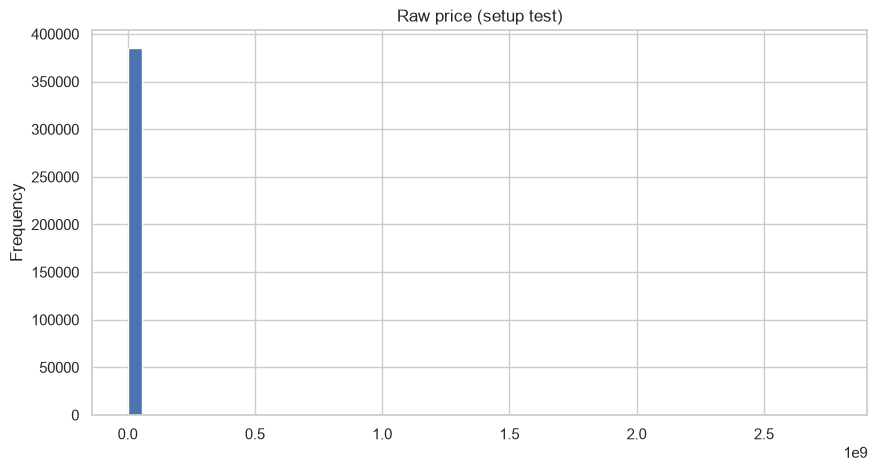

,step,observation,evidence,decision
0,1-Structure,"384,977 rows x 22 columns; mix of numeric, bin...","df.shape, df.info(), data dictionary",Handle each variable type with its own preproc...
1,1-Structure,region has 404 categories of mixed geographic ...,"df['region'].nunique(), region value_counts",One-hot encoding impractical; consider groupin...
2,1-Structure,region names are not unique locations: some na...,region vs region_url mapping check (1.7),Create unique location key from region_url (or...
3,1-Structure,Binary flags stored as integers; beds/baths ar...,df.dtypes vs true variable types,Treat flags as categorical 0/1; keep beds/bath...
4,1-Structure,"price ranges from 0 to 2,768,307,249",describe() on numeric columns,Investigate target extremes in Step 2
5,0-Setup,"Dataset loaded: 384,977 rows x 22 columns",df.shape after pd.read_csv,Use df_raw as untouched reference; all work on...


In [7]:
# 0.7 Test that everything works

log_obs(
    step="0-Setup",
    observation=f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns",
    evidence="df.shape after pd.read_csv",
    decision="Use df_raw as untouched reference; all work on df copy",
)

df["price"].plot(kind="hist", bins=50, title="Raw price (setup test)")
save_fig("00_setup_test")
plt.show()
show_obs()

## Step 1 – Structure and meaning of the data

Goal: understand exactly what each column is before analysing anything.

In [8]:
# 1.1 First look at the data

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
display(df.head(3))
display(df.tail(3))
display(df.sample(5, random_state=RANDOM_STATE))

Rows: 384,977  |  Columns: 22


,id,url,region,region_url,price,type,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,image_url,description,lat,long,state
0,7049044568,https://reno.craigslist.org/apa/d/reno-beautif...,reno / tahoe,https://reno.craigslist.org,1148,apartment,1078,3,2.00,1,1,0,0,0,0,w/d in unit,carport,https://images.craigslist.org/01616_daghmBUvTC...,Ridgeview by Vintage is where you will find al...,39.55,-119.80,ca
1,7049047186,https://reno.craigslist.org/apa/d/reno-reduced...,reno / tahoe,https://reno.craigslist.org,1200,condo,1001,2,2.00,0,0,0,0,0,0,w/d hookups,carport,https://images.craigslist.org/00V0V_5va0MkgO9q...,Conveniently located in the middle town of Ren...,39.50,-119.79,ca
2,7043634882,https://reno.craigslist.org/apa/d/sparks-state...,reno / tahoe,https://reno.craigslist.org,1813,apartment,1683,2,2.00,1,1,1,0,0,0,w/d in unit,attached garage,https://images.craigslist.org/00t0t_erYqC6LgB8...,2BD | 2BA | 1683SQFTDiscover exceptional servi...,39.63,-119.71,ca


,id,url,region,region_url,price,type,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,image_url,description,lat,long,state
384974,7049050454,https://reno.craigslist.org/apa/d/sparks-1mont...,reno / tahoe,https://reno.craigslist.org,1249,apartment,840,2,1.00,1,1,1,0,0,0,laundry on site,off-street parking,https://images.craigslist.org/01111_kr3uKMhzrf...,***Newly MODERNIZED Apartment Home*** âï¸ ...,39.54,-119.75,ca
384975,7049050149,https://reno.craigslist.org/apa/d/sparks-ready...,reno / tahoe,https://reno.craigslist.org,1429,apartment,976,2,2.00,1,1,1,0,0,0,w/d in unit,carport,https://images.craigslist.org/00c0c_1GslcQnpLP...,Welcome Home We welcome you to The Villas at D...,39.56,-119.70,ca
384976,7049050010,https://reno.craigslist.org/apa/d/reno-2x2-thi...,reno / tahoe,https://reno.craigslist.org,1295,apartment,957,2,2.00,1,1,1,0,0,0,w/d in unit,carport,https://images.craigslist.org/00O0O_atyH2pgYeH...,MOVE IN SPECIAL FREE WASHER/DRYER WITH 6 OR 12...,39.45,-119.77,ca


,id,url,region,region_url,price,type,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,image_url,description,lat,long,state
144026,7027550434,https://worcester.craigslist.org/apa/d/worcest...,worcester / central MA,https://worcester.craigslist.org,1750,apartment,936,2,1.00,1,0,1,0,0,0,NaN,NaN,https://images.craigslist.org/00909_clc5ZNuxjS...,VIEW OUR WEBSITE: https://www.winncompanies.c...,42.25,-71.85,ma
304025,7033922487,https://mcallen.craigslist.org/apa/d/mcallen-s...,mcallen / edinburg,https://mcallen.craigslist.org,850,apartment,1200,2,2.50,0,0,0,0,0,0,w/d in unit,off-street parking,https://images.craigslist.org/00Z0Z_jDGwUbmwXN...,"2 bedrooms, 2.5 baths, refrigerator, stove, wa...",26.22,-98.24,tx
23458,7045296557,https://fortcollins.craigslist.org/apa/d/lovel...,fort collins / north CO,https://fortcollins.craigslist.org,1500,apartment,1029,2,1.00,1,1,0,0,0,0,w/d in unit,off-street parking,https://images.craigslist.org/00404_8FWu5rgCAO...,Brand New 2 bed 1 bath apartment will go FAST ...,40.38,-105.09,co
100916,7031700539,https://indianapolis.craigslist.org/apa/d/indi...,indianapolis,https://indianapolis.craigslist.org,899,apartment,856,2,1.00,1,1,1,0,0,0,laundry in bldg,NaN,https://images.craigslist.org/00S0S_laAvyoi6Lj...,Check out what these 2 bedrooms @ Teal Run hav...,39.79,-85.98,in
225023,7048945590,https://cincinnati.craigslist.org/apa/d/cincin...,cincinnati,https://cincinnati.craigslist.org,595,apartment,350,0,1.00,0,0,0,0,0,0,no laundry on site,off-street parking,https://images.craigslist.org/00Y0Y_cGSqXWgG3F...,Completely renovated with an urban flare. 3rd ...,39.13,-84.53,oh


In [9]:
# 1.2 Storage data types

# What: See how pandas stored each column (int, float, or object/text) and how many non-null values each has.

# Why: The storage type pandas guesses is not always the true nature of the variable. The binary flags are stored as integers but are really yes/no categories. beds is stored as a number but only takes whole values. Spotting these mismatches tells us what conversions preprocessing needs.

df.info(memory_usage="deep")

# Findings to note: the dtype of each column. Also note any column with fewer non-null values than total rows, since those have missing values that we'll analyse in Step 3.

<class 'pandas.DataFrame'>
RangeIndex: 384977 entries, 0 to 384976
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       384977 non-null  int64  
 1   url                      384977 non-null  str    
 2   region                   384977 non-null  str    
 3   region_url               384977 non-null  str    
 4   price                    384977 non-null  int64  
 5   type                     384977 non-null  str    
 6   sqfeet                   384977 non-null  int64  
 7   beds                     384977 non-null  int64  
 8   baths                    384977 non-null  float64
 9   cats_allowed             384977 non-null  int64  
 10  dogs_allowed             384977 non-null  int64  
 11  smoking_allowed          384977 non-null  int64  
 12  wheelchair_access        384977 non-null  int64  
 13  electric_vehicle_charge  384977 non-null  int64  
 14  comes_furnished

In [10]:
# 1.3 Cardinality: number of unique values per column

# What: Count distinct values per column.

# Why: Cardinality helps classify variables. Two unique values means binary. A few means low-cardinality categorical. Hundreds means high-cardinality categorical, which matters because one-hot encoding hundreds of values creates hundreds of columns. Nearly all rows unique means an identifier or free text, which is not directly usable as a feature.

card = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "unique_%_of_rows": (df.nunique() / len(df) * 100).round(2),
}).sort_values("n_unique")
card

# Findings to note: which columns are binary, which are low-cardinality, which are high-cardinality (expect region), and which are near-unique (id, url, likely description and image_url).

,dtype,n_unique,unique_%_of_rows
wheelchair_access,int64,2,0.00
smoking_allowed,int64,2,0.00
electric_vehicle_charge,int64,2,0.00
comes_furnished,int64,2,0.00
dogs_allowed,int64,2,0.00
cats_allowed,int64,2,0.00
laundry_options,str,5,0.00
parking_options,str,7,0.00
beds,int64,11,0.00
type,str,12,0.00


In [11]:
# 1.4 Categorical columns: what values do they take?

# What: List the categories and their frequencies for the categorical columns.

# Why: This reveals rare categories that may need grouping, inconsistent labels, and whether any category looks invalid for a rental dataset (for example land).


cat_cols = ["type", "laundry_options", "parking_options"]
for col in cat_cols:
    print(f"\n=== {col} ===")
    vc = df[col].value_counts(dropna=False)
    display(pd.DataFrame({"count": vc,
                          "percent": (vc / len(df) * 100).round(2)}))


# dropna=False makes missing values appear as their own row (NaN). That's an early preview of Step 3.


=== type ===


,count,percent
type,,
apartment,318032,82.61
house,33266,8.64
townhouse,15885,4.13
condo,6238,1.62
duplex,5047,1.31
manufactured,4242,1.10
cottage/cabin,861,0.22
loft,693,0.18
flat,531,0.14



=== laundry_options ===


,count,percent
laundry_options,,
w/d in unit,131783,34.23
NaN,79026,20.53
w/d hookups,75568,19.63
laundry on site,58873,15.29
laundry in bldg,36103,9.38
no laundry on site,3624,0.94



=== parking_options ===


,count,percent
parking_options,,
NaN,140687,36.54
off-street parking,128502,33.38
attached garage,40591,10.54
carport,38955,10.12
detached garage,16940,4.40
street parking,15951,4.14
no parking,3188,0.83
valet parking,163,0.04


In [12]:
# 1.4 (cont.) State and region values

# state and region have many values, so look at them separately.

print("Unique states:", df["state"].nunique())
print(sorted(df["state"].dropna().unique()))

print("\nUnique regions:", df["region"].nunique())
print("Most frequent regions:")
display(df["region"].value_counts().head(10))
print("Least frequent regions:")
display(df["region"].value_counts().tail(10))

# Why the state count matters: the US has 50 states plus DC, which makes 51. More than 51 would suggest invalid codes, and fewer suggests some states have no listings.

# Why look at region names: Craigslist regions are not a consistent unit. Some are cities, some are metro areas, some are counties, and some are whole states or rural zones. Our proposal already flags this "different geographic granularity" issue, so this output is the evidence for it.

# Findings to note: the dominant and rare type values, the laundry and parking categories, the number of states, the number of regions, and examples showing mixed region granularity.

Unique states: 51
['ak', 'al', 'ar', 'az', 'ca', 'co', 'ct', 'dc', 'de', 'fl', 'ga', 'hi', 'ia', 'id', 'il', 'in', 'ks', 'ky', 'la', 'ma', 'md', 'me', 'mi', 'mn', 'mo', 'ms', 'mt', 'nc', 'nd', 'ne', 'nh', 'nj', 'nm', 'nv', 'ny', 'oh', 'ok', 'or', 'pa', 'ri', 'sc', 'sd', 'tn', 'tx', 'ut', 'va', 'vt', 'wa', 'wi', 'wv', 'wy']

Unique regions: 404
Most frequent regions:


region
jacksonville              4246
columbus                  3738
rochester                 3677
jackson                   3667
fayetteville              3652
fredericksburg            2747
omaha / council bluffs    2727
salt lake city            2719
denver                    2671
seattle-tacoma            2626
Name: count, dtype: int64

Least frequent regions:


region
west virginia (old)    19
owensboro              18
twin tiers NY/PA       18
pierre / central SD    18
susanville             15
southwest MS           12
st louis                9
southwest TX            9
fort smith, AR          5
kansas city             3
Name: count, dtype: int64

In [13]:
# 1.5 Validate the binary flags

# What: Confirm the six yes/no columns only contain 0 and 1.

# Why: Scraped data sometimes has stray values like 2 or -1. If a flag has anything other than 0 and 1, it needs cleaning before it's used.

binary_cols = ["cats_allowed", "dogs_allowed", "smoking_allowed",
               "wheelchair_access", "electric_vehicle_charge", "comes_furnished"]

binary_check = pd.DataFrame({
    "unique_values": [sorted(df[c].dropna().unique().tolist()) for c in binary_cols],
    "percent_yes": [(df[c].mean() * 100).round(2) for c in binary_cols],
}, index=binary_cols)
binary_check

# Findings to note: whether all flags are valid 0/1, and the share of "yes" for each. A very low share (EV charging is probably rare) means that feature carries little information.

,unique_values,percent_yes
cats_allowed,"[0, 1]",72.69
dogs_allowed,"[0, 1]",70.79
smoking_allowed,"[0, 1]",73.18
wheelchair_access,"[0, 1]",8.21
electric_vehicle_charge,"[0, 1]",1.29
comes_furnished,"[0, 1]",4.81


In [14]:
# 1.6 Numeric columns: first-glance summary

# What: Basic statistics for the numeric columns.

# Why: This is a quick sanity scan, not the full analysis. Steps 2, 5 and 6 go deeper. Comparing min, median, and max is often enough to reveal impossible values, such as a max bedroom count in the hundreds or a price of 0.

num_cols = ["price", "sqfeet", "beds", "baths", "lat", "long"]
display(df[num_cols].describe(percentiles=[.01, .25, .5, .75, .99]).T)

# Also check whether baths uses half-baths (1.5, 2.5), which is normal in US listings:

frac_baths = (df["baths"] % 1 != 0).mean() * 100
print(f"Listings with fractional baths: {frac_baths:.2f}%")
print(sorted(df["baths"].dropna().unique().tolist()))

# Findings to note: any min or max that is clearly impossible, and the gap between the 99th percentile and the max. A huge gap means extreme outliers. Also note that baths is discrete in steps of 0.5, not truly continuous.

,count,mean,std,min,1%,25%,50%,75%,99%,max
price,"384,977.00","8,825.72","4,462,199.88",0.00,344.00,805.00,"1,036.00","1,395.00","3,395.00","2,768,307,249.00"
sqfeet,"384,977.00","1,059.90","19,150.76",0.00,340.00,750.00,949.00,"1,150.00","2,405.00","8,388,607.00"
beds,"384,977.00",1.91,3.49,0.00,0.00,1.00,2.00,2.00,4.00,"1,100.00"
baths,"384,977.00",1.48,0.62,0.00,1.00,1.00,1.00,2.00,3.00,75.00
lat,"383,059.00",37.23,5.55,-43.53,26.17,33.45,37.65,41.14,48.20,102.04
long,"383,059.00",-92.70,16.53,-163.89,-147.37,-100.78,-87.75,-81.18,-71.30,172.63


Listings with fractional baths: 10.86%
[0.0, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 25.0, 35.0, 75.0]


In [15]:
# 1.7 Identifier and URL columns

# What: Test whether id and url are unique, and whether region_url is just a duplicate of region.

# Why: Identifiers have no predictive meaning. If region_url maps one-to-one onto region, it's redundant information and should be dropped. If id is unique but the same listing appears under different IDs, that shows reposting, which is the duplicate problem in Step 4.

print("id unique?        ", df["id"].is_unique)
print("url unique?       ", df["url"].is_unique)
print("image_url unique values:", f"{df['image_url'].nunique():,}", "of", f"{len(df):,}")

# One-to-one test: each region should have exactly one region_url and vice versa
print("Max region_urls per region:", df.groupby("region")["region_url"].nunique().max())
print("Max regions per region_url:", df.groupby("region_url")["region"].nunique().max())

# How to read it: If both maximums are 1, the mapping is one-to-one, so region_url is redundant. If image_url has far fewer unique values than there are rows, many listings share the same photo. That's a strong signal of reposted duplicates, which we'll quantify in Step 4.

# Findings to note: the uniqueness results and the conclusion about region_url.

id unique?         True
url unique?        True
image_url unique values: 181,068 of 384,977
Max region_urls per region: 3
Max regions per region_url: 2


In [16]:
# 1.7 (cont.) Which region names map to more than one Craigslist site?

multi = df.groupby("region")["region_url"].nunique()
ambiguous = multi[multi > 1].index
print(f"{len(ambiguous)} region names are shared by multiple Craigslist sites")
display(df[df["region"].isin(ambiguous)]
        .groupby(["region", "region_url"]).size()
        .rename("listings"))

11 region names are shared by multiple Craigslist sites


region        region_url                          
albany        https://albany.craigslist.org           1244
              https://albanyga.craigslist.org          846
athens        https://athensga.craigslist.org         1158
              https://athensohio.craigslist.org        101
charleston    https://charleston.craigslist.org       2441
              https://charlestonwv.craigslist.org      118
columbus      https://columbus.craigslist.org         2149
              https://columbusga.craigslist.org       1589
fayetteville  https://fayar.craigslist.org            1021
              https://fayetteville.craigslist.org     2631
jackson       https://jackson.craigslist.org          2274
              https://jacksontn.craigslist.org        1146
              https://jxn.craigslist.org               247
jacksonville  https://jacksonville.craigslist.org     2580
              https://onslow.craigslist.org           1666
monroe        https://monroe.craigslist.org            234
     

In [17]:
# 1.8 Build the data dictionary

# What: Create one table describing every column: its meaning, storage type, true variable type, number of unique values, and planned role.

# Why: This is the core Stage 3 deliverable for "understand the structure and meaning" and "identify variable types." It goes straight into our report. Separating the storage type (how pandas saved it) from the variable type (what it really is) shows understanding, which is exactly what the vivas probe.

dictionary_info = {
    # column: (meaning, variable type, planned role)
    "id": ("Unique Craigslist listing identifier", "Identifier", "Drop (no predictive meaning)"),
    "url": ("Web address of the listing", "Identifier", "Drop"),
    "region": ("Craigslist regional site the listing was posted on", "Nominal categorical (high cardinality)", "Feature (needs encoding/grouping)"),
    "region_url": ("Web address of the Craigslist regional site", "Nominal categorical (high cardinality)", "Unique location key (replaces region; region names are ambiguous)"),
    "price": ("Advertised monthly rent in USD", "Continuous numeric", "TARGET"),
    "type": ("Property type (apartment, house, condo, ...)", "Nominal categorical", "Feature"),
    "sqfeet": ("Floor area in square feet", "Continuous numeric", "Feature"),
    "beds": ("Number of bedrooms", "Discrete numeric", "Feature"),
    "baths": ("Number of bathrooms (half-baths as .5)", "Discrete numeric", "Feature"),
    "cats_allowed": ("1 if cats are allowed", "Binary", "Feature"),
    "dogs_allowed": ("1 if dogs are allowed", "Binary", "Feature"),
    "smoking_allowed": ("1 if smoking is allowed", "Binary", "Feature"),
    "wheelchair_access": ("1 if wheelchair accessible", "Binary", "Feature"),
    "electric_vehicle_charge": ("1 if EV charging available", "Binary", "Feature"),
    "comes_furnished": ("1 if furnished", "Binary", "Feature"),
    "laundry_options": ("Laundry facility type", "Nominal categorical", "Feature"),
    "parking_options": ("Parking facility type", "Nominal categorical", "Feature"),
    "image_url": ("Web address of the listing's main photo", "Identifier", "Drop (use only to detect duplicates)"),
    "description": ("Free-text listing description written by the poster", "Unstructured text", "Leakage check (may contain price)"),
    "lat": ("Latitude of the listing", "Continuous numeric (geographic)", "Feature (after validity check)"),
    "long": ("Longitude of the listing", "Continuous numeric (geographic)", "Feature (after validity check)"),
    "state": ("Two-letter state code of the Craigslist site (may not match the true location)", "Nominal categorical", "Feature (after validity check)"),
}

data_dict = pd.DataFrame([
    {
        "column": col,
        "meaning": dictionary_info[col][0],
        "storage_dtype": str(df[col].dtype),
        "variable_type": dictionary_info[col][1],
        "n_unique": df[col].nunique(),
        "missing_%": round(df[col].isna().mean() * 100, 2),
        "planned_role": dictionary_info[col][2],
    }
    for col in df.columns
])

data_dict.to_csv(REPORT_DIR / "data_dictionary.csv", index=False)
data_dict

,column,meaning,storage_dtype,variable_type,n_unique,missing_%,planned_role
0,id,Unique Craigslist listing identifier,int64,Identifier,384977,0.00,Drop (no predictive meaning)
1,url,Web address of the listing,str,Identifier,384977,0.00,Drop
2,region,Craigslist regional site the listing was poste...,str,Nominal categorical (high cardinality),404,0.00,Feature (needs encoding/grouping)
3,region_url,Web address of the Craigslist regional site,str,Nominal categorical (high cardinality),413,0.00,Unique location key (replaces region; region n...
4,price,Advertised monthly rent in USD,int64,Continuous numeric,3961,0.00,TARGET
5,type,"Property type (apartment, house, condo, ...)",str,Nominal categorical,12,0.00,Feature
6,sqfeet,Floor area in square feet,int64,Continuous numeric,3277,0.00,Feature
7,beds,Number of bedrooms,int64,Discrete numeric,11,0.00,Feature
8,baths,Number of bathrooms (half-baths as .5),float64,Discrete numeric,20,0.00,Feature
9,cats_allowed,1 if cats are allowed,int64,Binary,2,0.00,Feature


In [18]:
# 1.9 Log the observations


log_obs("1-Structure",
        f"{df.shape[0]:,} rows x {df.shape[1]} columns; mix of numeric, binary, categorical, identifier and text fields",
        "df.shape, df.info(), data dictionary",
        "Handle each variable type with its own preprocessing path")

log_obs("1-Structure",
        f"region has {df['region'].nunique()} categories of mixed geographic granularity",
        "df['region'].nunique(), region value_counts",
        "One-hot encoding impractical; consider grouping or target encoding fitted on train only")

log_obs("1-Structure",
        "region names are not unique locations: some names map to up to 3 Craigslist sites "
        "(e.g. jacksonville, columbus, rochester exist in multiple states)",
        "region vs region_url mapping check (1.7)",
        "Create unique location key from region_url (or region + state); drop id, url, image_url from features")

log_obs("1-Structure",
        "Binary flags stored as integers; beds/baths are discrete",
        "df.dtypes vs true variable types",
        "Treat flags as categorical 0/1; keep beds/baths numeric")

log_obs("1-Structure",
        f"price ranges from {df['price'].min():,.0f} to {df['price'].max():,.0f}",
        "describe() on numeric columns",
        "Investigate target extremes in Step 2")

show_obs()

,step,observation,evidence,decision
0,0-Setup,"Dataset loaded: 384,977 rows x 22 columns",df.shape after pd.read_csv,Use df_raw as untouched reference; all work on...
1,1-Structure,"384,977 rows x 22 columns; mix of numeric, bin...","df.shape, df.info(), data dictionary",Handle each variable type with its own preproc...
2,1-Structure,region has 404 categories of mixed geographic ...,"df['region'].nunique(), region value_counts",One-hot encoding impractical; consider groupin...
3,1-Structure,region names are not unique locations: some na...,region vs region_url mapping check (1.7),Create unique location key from region_url (or...
4,1-Structure,Binary flags stored as integers; beds/baths ar...,df.dtypes vs true variable types,Treat flags as categorical 0/1; keep beds/bath...
5,1-Structure,"price ranges from 0 to 2,768,307,249",describe() on numeric columns,Investigate target extremes in Step 2


# Notebook Explanation – What We Did and Why

This notebook covers **Step 0 (setup)** and **Step 1 (structure and meaning of the data)**. Cells are referred to by the section number on their first line, e.g. **0.3** or **1.7**.

## What are we actually doing?

The goal of the project is to build a model that predicts monthly rent from property details. But you can't build a good model from data you don't understand. The dataset was scraped from Craigslist, where anyone can type anything, so it's full of errors, repeats, and gaps.

**EDA (Exploratory Data Analysis)** is the investigation phase. We act like a detective checking every column before trusting it. The output isn't a model. It's a list of *findings* and the *decisions* they lead to. For example: "Some prices are \$0, so we must remove those rows before training."

The notebook so far does two things:

1. **Setup:** loads the data safely and creates tools for recording findings.
2. **Step 1:** figures out what each of the 22 columns is and what it contains.

---

# Part A: Setup (0.1 – 0.7)

### 0.1 – Imports and settings

This cell loads pandas (tables), numpy (maths), and matplotlib and seaborn (charts), then imports the shared helpers from `src/utils.py`. `sys.path.append(...)` is needed because the notebook runs from inside `notebooks/`, and Python only looks for modules in the current folder by default.

`RANDOM_STATE = 42` (defined in `utils.py`) fixes randomness. Whenever we pick random rows, we get the *same* random rows every time, so results can be reproduced. That is reproducibility, which our proposal promises. The number 42 itself has no meaning; any fixed number works.

`setup_display()` just makes tables readable: it shows all 22 columns, and the float format stops pandas from showing prices like `1.5e+09`. It also gives every chart the same style for the report.

### 0.2 – File paths

The folder paths (raw data, intermediate files, figures, reports) are defined once in `utils.py`, and missing folders are created automatically. Keeping them in one file means every notebook points at the same places.

We use `pathlib` because it builds paths that work on both Windows and Mac, which avoids broken paths between group members.

**Output:** The CSV exists and is **558 MB**, which is large and explains why loading it is slow.

### 0.3 – Loading the data

This reads the CSV into a table called `df_raw`.

`low_memory=False` makes pandas read the whole file before guessing each column's type. This avoids "mixed types" warnings on messy scraped data.

**Output:** **384,977 rows × 22 columns, using about 600 MB of memory**. Each row is one rental listing. Each column is one piece of information about it.

### 0.4 – Verification

This checks that we got exactly the dataset promised in our proposal.

**Output:** All 22 expected columns are present, there are no extras, and the row count matches 384,977. This is our first piece of evidence: the data matches the approved proposal.

### 0.5 – Safety copies

Two things happen here:

- A **parquet** copy is saved. Parquet is a compressed format that loads in seconds, while the CSV takes minutes. In later sessions we can start with `pd.read_parquet(...)` instead of reading the CSV.
- `df = df_raw.copy()` creates a working copy. We change `df` freely, while `df_raw` stays untouched as the original, just in case.

### Helpers in `utils.py` – observations log and figure saver

`log_obs()` writes each finding into `reports/observations_log.csv`. Think of it as a lab notebook. By the end, this file becomes our "observations → decisions" table for the report (Step 13). It reads the existing file and appends to it, so findings logged from different notebooks all end up in the same table, and re-running a cell won't add the same entry twice.

`show_obs()` displays the log.

`save_fig()` saves each chart as an image in `reports/figures/`, ready for the report.

### 0.6 – Plotting sample

`df_plot = plot_sample(df)` is a random 50,000-row sample used **only for drawing charts**, because plotting 385k dots is slow and unreadable. All statistics always use the full data. Because of the fixed seed, the sample is the same every run. It will be re-drawn after cleaning, so later charts don't include invalid rows.

### 0.7 – Test

This checks that all the tools work: it logs the first observation and saves a histogram of raw price.

**Output:** Both helpers work. The histogram looks like one tall bar at the left. That happens because a few absurd prices (billions!) stretch the axis. It's the first clue of problems in the data.

---

# Part B: Step 1 – Understanding Each Column (1.1 – 1.9)

### 1.1 – First look

This shows real rows: the first 3, the last 3, and 5 random ones. `head()` alone can mislead, because the first rows are often cleaner than the rest, so random rows show what typical records actually look like.

**What the output tells us:** Most rows look like normal listings: Reno apartments at \$1,100–1,800 with 1–3 beds. Two things are worth noticing.

**Row 4 is a \$289/month apartment of 250 sqft with 0 beds.** It's furnished and "move in today," so it's probably a room or short-term rental, not a normal apartment. That's an early hint that unusual listings are mixed in.

**The Reno listings say `state = ca`.** The coordinates (39.5, -119.8) are Reno, which is in **Nevada**, not California. So the `state` column isn't always the property's real state. It seems to come from how Craigslist grouped the site (Reno/Tahoe spans both states). We will check this properly in Step 5 by comparing `state` against the coordinates.

### 1.2 – Storage data types

`df.info()` shows how pandas stored each column and how many values are filled in.

**What the output tells us:** There are two main takeaways.

**Missing values exist in four columns:**

| Column | Missing | % |
|---|---|---|
| parking_options | 140,687 | 36.5% |
| laundry_options | 79,026 | 20.5% |
| lat / long | 1,918 | 0.5% |
| description | 2 | ~0% |

We'll analyse these in Step 3.

**Storage type ≠ real meaning.** The six yes/no flags are stored as integers (`int64`), but they're really categories: 1 means yes and 0 means no. Averaging them like normal numbers would be meaningless.

### 1.3 – Cardinality

Cardinality means the number of distinct values in a column. It tells us what kind of variable each column is.

**What the output tells us:**

| Unique values | Columns | Meaning |
|---|---|---|
| 2 | the six flags | binary (yes/no) |
| 5–51 | laundry, parking, type, beds, baths, state | small categories or small counts |
| 404 | region | **high-cardinality** category, hard to encode |
| thousands | sqfeet, price, lat, long | real numeric measurements |
| 181,068 | image_url | many listings **share photos** |
| 280,836 | description | many listings **share text** |
| 384,977 (100%) | id, url | unique per row, meaning identifiers |

Two numbers here matter a lot:

- **image_url:** only 181,068 unique photos across 384,977 listings. More than half the listings reuse a photo from another listing.
- **description:** about 27% of descriptions are repeats.

This strongly suggests the **same apartments were posted multiple times**. Those repeats would unfairly inflate the model's test score if copies end up in both training and test data. That's what Step 4 is for.

### 1.4 – Categorical values (type, laundry, parking)

This lists every category with its count and percentage. `dropna=False` makes missing values appear as their own row (`NaN`), an early preview of Step 3.

**What the output tells us:**

**`type`:** Apartments dominate at 82.6%. Several types are rare (in-law, loft, flat, cottage). Two are suspicious for a rental dataset: **land (8 rows)** and **assisted living (2 rows)**. These will likely be removed or grouped into "other."

**`laundry_options` and `parking_options`:** Each has a few clear categories plus a large NaN (missing) group. When a poster leaves parking blank, it may mean "no parking info" or even "no parking," and that could relate to price. Step 3 tests this.

### 1.4 (cont.) – State and region values

`state` and `region` have many values, so we look at them separately.

**What the output tells us:**

**`state`:** Exactly 51 codes, meaning 50 states plus DC. All are valid codes, although, as we saw with Reno, they don't always match the real location.

**`region`:** There are 404 regions, ranging from 4,246 listings (Jacksonville) down to just 3 (Kansas City). Also notice the mix of units. Some are cities ("denver"), some are metro areas ("omaha / council bluffs"), and some are broad zones ("southwest TX"). That's the "inconsistent geographic granularity" our proposal predicted.

### 1.5 – Binary flags

This confirms the six flags only contain 0 and 1, and shows the percentage of "yes" for each.

**What the output tells us:** All six flags contain only 0 and 1, so there's no invalid data. The share of "yes" matters:

- EV charging: **1.3%**, furnished: **4.8%**, wheelchair: **8.2%**. These are rare, so each carries limited information and may have weak predictive power.
- Smoking allowed: **73%**. That's surprisingly high for US rentals. It might mean Craigslist defaults this box to "allowed" when the poster doesn't specify. It's worth mentioning in the report as a data-reliability limitation.

### 1.6 – Numeric summary

This is a quick sanity scan of the numeric columns, not the full analysis; Steps 2, 5 and 6 go deeper. Comparing the median, the 99th percentile, and the maximum is often enough to reveal impossible values. The cell also checks whether `baths` uses half-baths.

**What the output tells us:**

| Column | Median | 99th percentile | Max | Why it's a problem |
|---|---|---|---|---|
| price | \$1,036 | \$3,395 | \$2,768,307,249 | min is \$0 and max is nearly \$2.8 billion a month |
| sqfeet | 949 | 2,405 | 8,388,607 | min is 0; max is impossible |
| beds | 2 | 4 | 1,100 | impossible |
| baths | 1 | 3 | 75 | impossible |
| lat | 37.65 | 48.20 | 102.04 | latitude can't exceed 90; min of -43.5 is in the southern hemisphere |
| long | -87.75 | -71.30 | 172.63 | positive longitude is outside the mainland US |

**Mean price is \$8,826, but the median is \$1,036.** The mean is dragged up massively by a few absurd values, so it's useless as a summary here. The median is the reliable figure. This already suggests we'll need a log transform and outlier handling for the target.

**`sqfeet` max is exactly 8,388,607.** That's 2²³ − 1, a typical "maximum value" placeholder produced by a system, not a real size.

**Half-baths:** 10.9% of listings have values like 1.5 or 2.5, which is normal in the US: a "half bath" is a toilet with no shower. But look at the end of the list: **25, 35 and 75 bathrooms**. Those are impossible for a rental, so they're data-entry errors.

The huge gap between the 99th percentile and the max in every column confirms extreme outliers and invalid values. We'll handle them in Steps 2, 5 and 6.

### 1.7 – Identifiers

This tests whether `id` and `url` are unique, counts unique photos, and checks whether `region_url` is just a duplicate of `region`. Identifiers have no predictive meaning, and if `region_url` mapped one-to-one onto `region`, it would be redundant.

**What the output tells us:** `id` and `url` are unique, as expected, so they are pure identifiers.

**The region result, though, disproves what we assumed:**

- **Max region_urls per region: 3.** One region name maps to up to 3 different Craigslist sites.
- **Max regions per region_url: 2.**

So `region` and `region_url` are **not** one-to-one, and `region_url` is **not** simply redundant. 1.7 (cont.) investigates why.

### 1.7 (cont.) – Which region names are ambiguous?

This lists every region name that belongs to more than one Craigslist site.

**What the output tells us:** **11 region names are shared by different places.** Look back at the most frequent regions in 1.4 (cont.): jacksonville, columbus, rochester, jackson, fayetteville. These are all **city names that exist in several states**:

| Region name | Actual places |
|---|---|
| jackson | Jackson MS, Jackson TN and Jackson MI (3 sites) |
| jacksonville | Jacksonville FL and Jacksonville NC (onslow) |
| columbus | Columbus OH and Columbus GA |
| rochester | Rochester NY and Rochester MN |
| fayetteville | Fayetteville NC and Fayetteville AR |

The others are albany, athens, charleston, monroe, richmond and springfield.

So the "most frequent regions" aren't really the biggest markets. Different cities with the same name got counted together. If we used `region` alone as a feature, the model would treat Jacksonville FL and Jacksonville NC as the same place. That's a genuine data-quality finding.

**Decision:** the true location unit is `region_url`, or equivalently `region` combined with `state`. So we will **build a unique region key** instead of dropping `region_url`.

### 1.8 – Data dictionary

This builds one summary table of all columns. For each column it gives the meaning, storage type, true variable type, unique count, % missing, and planned role, and it saves the table to `reports/data_dictionary.csv`. This table goes straight into our report.

Separating the *storage type* (how pandas saved it) from the *variable type* (what it really is) shows real understanding of the data. Because of the 1.7 (cont.) finding, `region_url` is recorded as the true region key, not as something to drop.

### 1.9 – Observation log

This records Step 1's findings and the decisions they lead to.

**What was logged:**

1. The data mixes numeric, binary, categorical, identifier, and text fields, so each variable type gets its own preprocessing path.
2. `region` has 404 categories of mixed granularity, so one-hot encoding is impractical. We'll consider grouping or target encoding, fitted on training data only.
3. Region names are not unique locations, so we'll create a unique location key from `region_url` (or `region` + `state`). `id`, `url` and `image_url` are dropped from the model features.
4. Binary flags are treated as categorical 0/1; beds and baths stay numeric.
5. Prices range from **\$0 to \$2,768,307,249**, nearly 2.8 billion dollars a month. That's obviously an error, and it's what Step 2 investigates.

---

# Summary of What Step 1 Found

The dataset matches the proposal: 384,977 listings and 22 columns. Each column has been classified: target, numeric, binary, categorical, identifier, or text. Several problems have surfaced, each of which later steps will handle:

| Problem found | Evidence | Handled in |
|---|---|---|
| Absurd prices (\$0 to \$2.8 billion); mean distorted by extremes | 1.6 | Step 2 |
| Parking 36.5% and laundry 20.5% missing | 1.2, 1.4 | Step 3 |
| Over half the listings reuse photos, 27% reuse descriptions | 1.3 | Step 4 |
| Impossible sqfeet, beds, baths (25, 35, 75) and coordinates (lat 102) | 1.6 | Step 5 |
| `state` sometimes doesn't match the location (Reno labelled `ca`) | 1.1 | Step 5 |
| Rare or odd property types (land, assisted living) | 1.4 | Steps 6 and 11 |
| 11 region names shared by different cities | 1.7, 1.7 (cont.) | Preprocessing (location key) |
| smoking_allowed possibly defaulted by Craigslist | 1.5 | Report limitation |